In [38]:
import pandas as pd
import matplotlib as plt


In [39]:
! pip install openpyxl

In [40]:
df = pd.read_excel('Chegovara_data.xlsx')

In [41]:
df

,user_id,name,account_type,level,status,created_at
0,1,مدیر سیستم,home,administrator,active,2018-10-11 16:15:26
1,3,علی پورسینا,home,customer,active,2018-10-12 22:37:54
2,4,پیمان فرج زاده,home,customer,active,2019-01-04 03:30:00
3,5,اردلان باربد,home,customer,active,2019-01-04 03:30:00
4,6,علی دادگر,home,customer,active,2019-01-04 03:30:00
...,...,...,...,...,...,...
16663,17212,Leila babaei,home,customer,active,2026-08-23 18:07:55
16664,17216,مونا عابدینی,home,customer,active,2026-08-24 11:45:31
16665,17218,آرش برهان زاده,home,customer,active,2026-08-24 12:10:13
16666,17219,کتایون صیرفیان,home,customer,active,2026-08-24 14:28:36


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16668 entries, 0 to 16667
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       16668 non-null  int64
 1   name          15384 non-null  str  
 2   account_type  16668 non-null  str  
 3   level         16668 non-null  str  
 4   status        16668 non-null  str  
 5   created_at    16668 non-null  str  
dtypes: int64(1), str(5)
memory usage: 1.7 MB


In [43]:
df.isna().sum()

user_id            0
name            1284
account_type       0
level              0
status             0
created_at         0
dtype: int64

In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df["status"].value_counts()


status
active      16651
inactive       17
Name: count, dtype: int64

In [46]:
df["account_type"].value_counts()

account_type
home          14389
company        1871
commercial      408
Name: count, dtype: int64

In [47]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["month"] = df["created_at"].dt.to_period("M")

In [48]:
df[["created_at", "month"]].head()


,created_at,month
0,2018-10-11 16:15:26,2018-10
1,2018-10-12 22:37:54,2018-10
2,2019-01-04 03:30:00,2019-01
3,2019-01-04 03:30:00,2019-01
4,2019-01-04 03:30:00,2019-01


In [49]:
monthly_customers = df.groupby("month").size()
monthly_customers

month
2018-10      2
2019-01    634
2019-02    116
2019-03    129
2019-04    154
          ... 
2026-04     42
2026-05     47
2026-06    118
2026-07    104
2026-08     97
Freq: M, Length: 93, dtype: int64

In [50]:
monthly_customers.sort_values(ascending=False).head(10)

month
2019-01    634
2023-07    489
2025-07    483
2021-08    458
2021-07    420
2022-08    402
2022-07    390
2019-07    364
2023-05    361
2023-06    354
Freq: M, dtype: int64

### we see the business is get slowly far from the first stage 
 2019 -> 600 
 2020 -> 100  

 2025-2026 -> 500
 2026-2027 -> 10
 # what was the problem that chgovara falls ?
 Maybe Cheguvara ran a campaign, changed pricing, or had another acquisition channel. 
 Then we can build the really important analysis:

Customer → Orders → Revenue → Location → Recency → Frequency → Value

That's where we'll discover exactly which customers Cheguvara should target to grow in Tehran.

<Axes: title={'center': 'New Customers per Month'}, xlabel='month'>

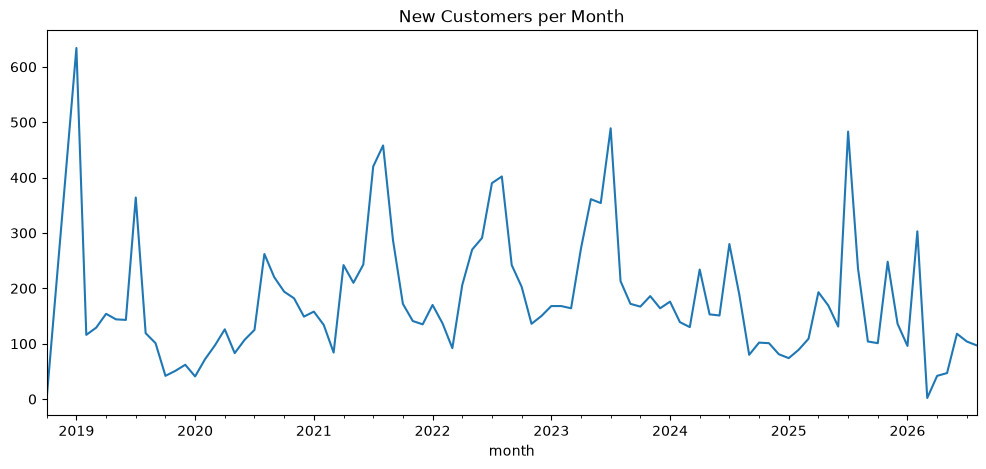

In [37]:
monthly_customers.plot(
    figsize=(12, 5),
    title="New Customers per Month"
)

In [21]:
df["created_at"].dtype

dtype('<M8[us]')

In [52]:
df["status"].value_counts(normalize=True) * 100

status
active      99.898008
inactive     0.101992
Name: proportion, dtype: float64

In [53]:
df["account_type"].value_counts()

account_type
home          14389
company        1871
commercial      408
Name: count, dtype: int64

In [54]:
today = pd.Timestamp("2026-08-26")

df["customer_days"] = (
    today - df["created_at"]
).dt.days

In [55]:
df["customer_days"].describe()

count    16668.000000
mean      1437.994540
std        749.227019
min          1.000000
25%        865.000000
50%       1456.000000
75%       1962.000000
max       2875.000000
Name: customer_days, dtype: float64

In [56]:
df["customer_age_group"] = pd.cut(
    df["customer_days"],
    bins=[0, 30, 90, 365, 730, float("inf")],
    labels=[
        "0-30 days",
        "31-90 days",
        "3-12 months",
        "1-2 years",
        "2+ years"
    ]
)

In [57]:
df["customer_age_group"].value_counts(normalize=True) * 100

customer_age_group
2+ years       80.267579
1-2 years      11.123110
3-12 months     6.665467
31-90 days      1.265899
0-30 days       0.677946
Name: proportion, dtype: float64

In [58]:
df["status"].value_counts()
df["account_type"].value_counts()
df["customer_age_group"].value_counts()

customer_age_group
2+ years       13379
1-2 years       1854
3-12 months     1111
31-90 days       211
0-30 days        113
Name: count, dtype: int64

In [59]:
monthly = (
    df.groupby(df["created_at"].dt.to_period("M"))
      .size()
)

monthly

created_at
2018-10      2
2019-01    634
2019-02    116
2019-03    129
2019-04    154
          ... 
2026-04     42
2026-05     47
2026-06    118
2026-07    104
2026-08     97
Freq: M, Length: 93, dtype: int64

In [60]:
df["year"] = df["created_at"].dt.year

yearly = df.groupby("year").size()

yearly

year
2018       2
2019    2059
2020    1658
2021    2684
2022    2689
2023    2878
2024    1816
2025    2073
2026     809
dtype: int64

In [61]:
yearly_growth = yearly.pct_change() * 100

yearly_growth

year
2018              NaN
2019    102850.000000
2020       -19.475474
2021        61.881785
2022         0.186289
2023         7.028635
2024       -36.900625
2025        14.151982
2026       -60.974433
dtype: float64

In [62]:
last_30 = df[
    df["created_at"] >= pd.Timestamp("2026-07-27")
]

len(last_30)

112

In [63]:
df["day_of_week"] = df["created_at"].dt.day_name()

df["day_of_week"].value_counts()

day_of_week
Monday       2685
Sunday       2599
Saturday     2575
Tuesday      2535
Wednesday    2432
Friday       1975
Thursday     1867
Name: count, dtype: int64

In [64]:
df["hour"] = df["created_at"].dt.hour

df["hour"].value_counts().sort_index()

hour
0      484
1      454
2      372
3      896
4      228
5      208
6      146
7      165
8      321
9      547
10     694
11     808
12     910
13    1030
14    1183
15    1309
16    1207
17    1045
18     968
19     954
20     847
21     688
22     655
23     549
Name: count, dtype: int64

In [65]:
df = df.copy()

df["created_at"] = pd.to_datetime(df["created_at"])

df["year"] = df["created_at"].dt.year
df["month"] = df["created_at"].dt.month
df["year_month"] = df["created_at"].dt.to_period("M")
df["day"] = df["created_at"].dt.day
df["hour"] = df["created_at"].dt.hour
df["weekday"] = df["created_at"].dt.day_name()

In [66]:
yearly = df.groupby("year").size()

yearly

year
2018       2
2019    2059
2020    1658
2021    2684
2022    2689
2023    2878
2024    1816
2025    2073
2026     809
dtype: int64

In [67]:
yearly_growth = yearly.pct_change() * 100

yearly_growth.round(2)

year
2018          NaN
2019    102850.00
2020       -19.48
2021        61.88
2022         0.19
2023         7.03
2024       -36.90
2025        14.15
2026       -60.97
dtype: float64

In [68]:
monthly = df.groupby("year_month").size()

In [69]:
monthly.tail(20)

year_month
2025-01     74
2025-02     89
2025-03    109
2025-04    193
2025-05    169
2025-06    131
2025-07    483
2025-08    236
2025-09    104
2025-10    101
2025-11    248
2025-12    136
2026-01     96
2026-02    303
2026-03      2
2026-04     42
2026-05     47
2026-06    118
2026-07    104
2026-08     97
Freq: M, dtype: int64

In [70]:
monthly.sort_values(ascending=False).head(10)

year_month
2019-01    634
2023-07    489
2025-07    483
2021-08    458
2021-07    420
2022-08    402
2022-07    390
2019-07    364
2023-05    361
2023-06    354
Freq: M, dtype: int64

In [71]:
monthly_ma = monthly.rolling(3).mean()

monthly_ma.tail(20)

year_month
2025-01     85.333333
2025-02     81.333333
2025-03     90.666667
2025-04    130.333333
2025-05    157.000000
2025-06    164.333333
2025-07    261.000000
2025-08    283.333333
2025-09    274.333333
2025-10    147.000000
2025-11    151.000000
2025-12    161.666667
2026-01    160.000000
2026-02    178.333333
2026-03    133.666667
2026-04    115.666667
2026-05     30.333333
2026-06     69.000000
2026-07     89.666667
2026-08    106.333333
Freq: M, dtype: float64

In [72]:
mean = monthly.mean()
std = monthly.std()

spikes = monthly[
    monthly > mean + 2 * std
]

spikes

year_month
2019-01    634
2021-07    420
2021-08    458
2023-07    489
2025-07    483
Freq: M, dtype: int64

In [74]:
seasonality = (
    df.groupby("month")
      .size()
)

In [75]:
monthly_avg = (
    df.groupby(["year", "month"])
      .size()
      .groupby("month")
      .mean()
)

monthly_avg

month
1     189.625000
2     144.750000
3     100.875000
4     183.625000
5     179.625000
6     192.250000
7     331.875000
8     247.000000
9     172.285714
10    122.875000
11    149.285714
12    125.285714
dtype: float64

In [76]:
hourly = df.groupby("hour").size()

hourly

hour
0      484
1      454
2      372
3      896
4      228
5      208
6      146
7      165
8      321
9      547
10     694
11     808
12     910
13    1030
14    1183
15    1309
16    1207
17    1045
18     968
19     954
20     847
21     688
22     655
23     549
dtype: int64

<Axes: title={'center': 'Customers by Registration Hour'}, xlabel='hour'>

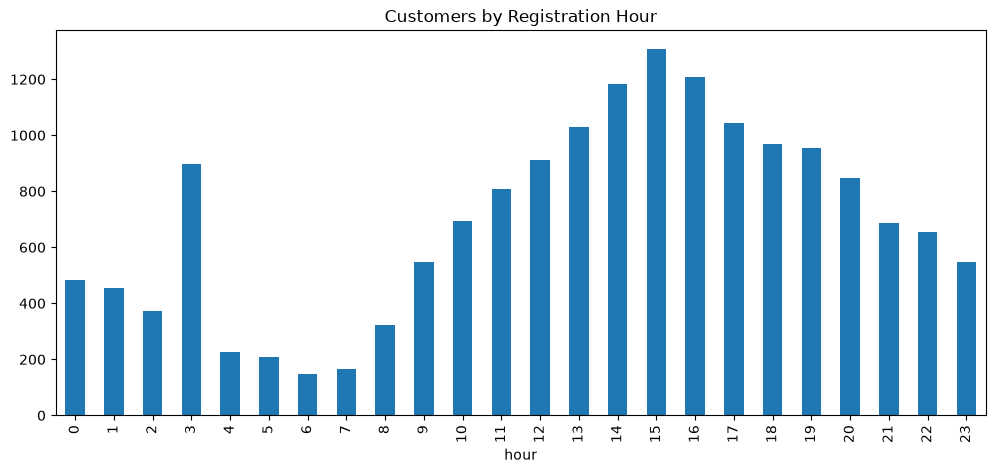

In [77]:
hourly.plot(
    kind="bar",
    figsize=(12,5),
    title="Customers by Registration Hour"
)

In [78]:
weekday = df["weekday"].value_counts()

In [79]:
order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday = (
    df["weekday"]
    .value_counts()
    .reindex(order)
)

weekday

weekday
Monday       2685
Tuesday      2535
Wednesday    2432
Thursday     1867
Friday       1975
Saturday     2575
Sunday       2599
Name: count, dtype: int64

In [80]:
today = pd.Timestamp("2026-08-26")

df["customer_days"] = (
    today - df["created_at"]
).dt.days

In [81]:
df["customer_days"].describe()

count    16668.000000
mean      1437.994540
std        749.227019
min          1.000000
25%        865.000000
50%       1456.000000
75%       1962.000000
max       2875.000000
Name: customer_days, dtype: float64

In [82]:
df["customer_days"].median()

np.float64(1456.0)

In [83]:
df["age_group"] = pd.cut(
    df["customer_days"],
    bins=[0, 30, 90, 180, 365, 730, float("inf")],
    labels=[
        "0-30 days",
        "31-90 days",
        "91-180 days",
        "181-365 days",
        "1-2 years",
        "2+ years"
    ]
)

In [84]:
df["age_group"].value_counts().sort_index()

age_group
0-30 days         113
31-90 days        211
91-180 days       128
181-365 days      983
1-2 years        1854
2+ years        13379
Name: count, dtype: int64

In [85]:
pd.crosstab(
    df["age_group"],
    df["status"],
    normalize="index"
).round(3) * 100

status,active,inactive
age_group,,
0-30 days,100.0,0.0
31-90 days,99.5,0.5
91-180 days,100.0,0.0
181-365 days,100.0,0.0
1-2 years,100.0,0.0
2+ years,99.9,0.1
